### Figure 4

created by Cassie Lumbrazo\
last updated: Sept 2026\
run location: UAS linux\
python environment: **xarray**

In [24]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy
import os

In [25]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites'

# Open Data and Model Simulations

## Function for Reading SMET Files 

In [26]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

### Open SNOWPACK SMet Output

In [48]:
ds_snowpack_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_hrrrak_lapserate, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet")
ds_snowpack_met_hrrrak, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_ppsa_WY2023-WY2025_base.smet")
# ds_snowpack_met_hrrrak_lapserate, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_lapserate_ppsa_WY2023-WY2025_base.smet") 
ds_snowpack_met_hrrrak_lapserate, header = read_smet("/home/cassie/python/models/run_snowpack/sites/ppsa/output/met_hrrrak_lapserate_ppsa_WY2020-WY2025_base.smet") # ppsa has WY2020-WY2025

/tmp/ipykernel_1482457/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


/tmp/ipykernel_1482457/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1482457/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/tmp/ipykernel_1482457/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [49]:
# the model have a "timestamp" instead of "time" dimension, so rename that for consistency
# xarray rename returns a new dataset unless inplace=False, so assign the result.
ds_snowpack_hrrrak = ds_snowpack_hrrrak.rename({"timestamp": "time"})
ds_snowpack_hrrrak_lapserate = ds_snowpack_hrrrak_lapserate.rename({"timestamp": "time"})
ds_snowpack_met_hrrrak = ds_snowpack_met_hrrrak.rename({"timestamp": "time"})
ds_snowpack_met_hrrrak_lapserate = ds_snowpack_met_hrrrak_lapserate.rename({"timestamp": "time"})

In [50]:
# cut the ds_snowpack_hrrrak to WY2023-WY2025 to match the met forcing snowpack run
# ds_snowpack_hrrrak = ds_snowpack_hrrrak.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))
ds_snowpack_hrrrak = ds_snowpack_hrrrak.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))
ds_snowpack_hrrrak_lapserate = ds_snowpack_hrrrak_lapserate.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))

### Open Observations

In [51]:
# # open observations
file = "/hdd/snow_hydrology/met_station/ppsa2/pppsa_met_station_data_synoptic_2026-03-20" 
ds_obs = xr.open_dataset(file)

# ds_obs = ds_obs.sel(time=slice("2019-10-01", "2022-09-30"))
ds_obs = ds_obs.sel(time=slice("2022-09-01", "2025-09-30"))
# ds_obs

In [52]:
# ds_snowpack_hrrrak
# ds_snowpack_hrrrak_lapserate
# ds_snowpack_met_hrrrak
# ds_obs

In [53]:
# df created in repo/juneau_field_data/1_create_snowpit_dataframe_WY2025.ipynb
# df.to_csv('/hdd/snow_hydrology/field_data/snow_pit_swe_measurements_WY2025.csv')
df_field_measurements = pd.read_csv('/hdd/snow_hydrology/field_data/snow_pit_swe_measurements_WY2025.csv', index_col=0, parse_dates=True)
df_field_measurements.head()

,snow_depth_cm,snow_depth_in,average_density,swe_mm,swe_m,swe_in
2025-01-23,126,49.606299,334,420.80,0.42080,16.566929
2025-01-28,123,48.425197,317,389.84,0.38984,15.348031
2025-02-12,133,52.362205,334,444.00,0.44400,17.480315
2025-02-16,130,51.181102,334,434.00,0.43400,17.086614
2025-02-20,128,50.393701,306,391.68,0.39168,15.420472


In [54]:
ds_snowpack_hrrrak = ds_snowpack_hrrrak.sel(time=slice("2024-09-01T05:00:00", "2025-07-30T05:00:00"))
ds_snowpack_hrrrak_lapserate = ds_snowpack_hrrrak_lapserate.sel(time=slice("2024-09-01T05:00:00", "2025-07-30T05:00:00"))
ds_snowpack_met_hrrrak = ds_snowpack_met_hrrrak.sel(time=slice("2024-09-01T05:00:00", "2025-07-30T05:00:00"))
ds_snowpack_met_hrrrak_lapserate = ds_snowpack_met_hrrrak_lapserate.sel(time=slice("2024-09-01T05:00:00", "2025-07-30T05:00:00"))
ds_obs = ds_obs.sel(time=slice("2024-09-01", "2025-07-30"))

In [55]:
ds_obs['hs'] = ds_obs['hs'].where(~((ds_obs['time'] >= np.datetime64("2024-08-20T00:00")) & (ds_obs['time'] <= np.datetime64("2024-10-15T23:59")))) # the spike in 2025

# Figure 4

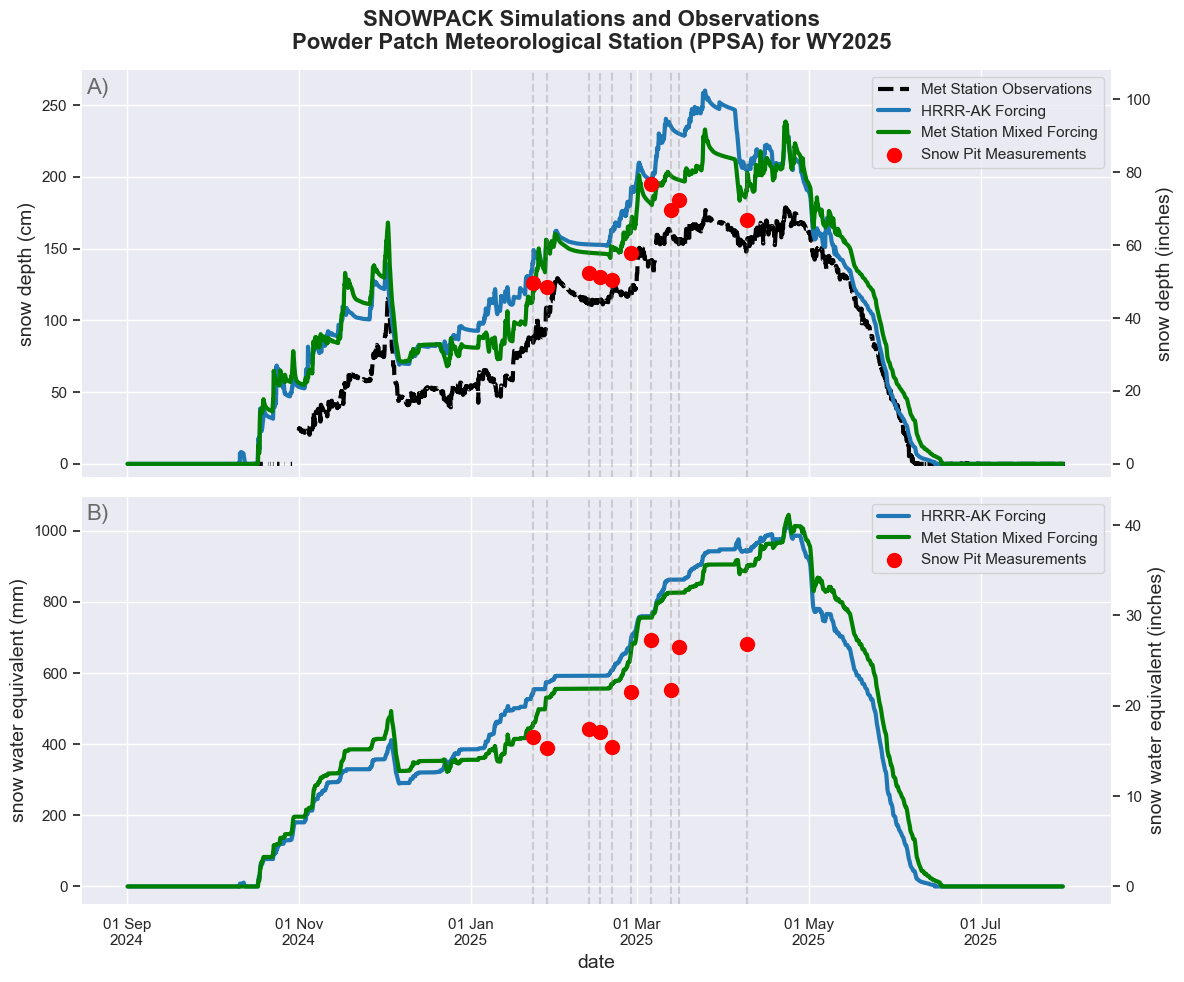

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# FIGURE 4
# PPSA WY2025 Snow Depth + SWE
# Final manuscript forcing configurations only
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 10),
    sharex=True
)

# ============================================================
# A) SNOW DEPTH
# ============================================================

# Continuous observed snow depth
ds_obs.hs.plot(
    ax=ax1,
    label='Met Station Observations',
    linewidth=3,
    linestyle='--',
    color='black'
)

# HRRR-AK forcing
# NOTE: this is the lapse-rate-corrected HRRR-AK dataset,
# but we refer to it simply as "HRRR-AK Forcing" in the paper.
ds_snowpack_hrrrak_lapserate.HS_mod.plot(
    ax=ax1,
    label='HRRR-AK Forcing',
    linewidth=3,
    color='tab:blue'
)

# Met Station Mixed forcing
# NOTE: HRRR-AK temperature used for gaps is lapse-rate corrected.
ds_snowpack_met_hrrrak_lapserate.HS_mod.plot(
    ax=ax1,
    label='Met Station Mixed Forcing',
    linewidth=3,
    color='green'
)

# Snow pit dates + observed snow depth
for i, date in enumerate(df_field_measurements.index):

    ax1.axvline(
        x=date,
        color='grey',
        linestyle='--',
        alpha=0.3
    )

    ax1.scatter(
        date,
        df_field_measurements.loc[date, 'snow_depth_cm'],
        color='red',
        s=100,
        zorder=5,
        label='Snow Pit Measurements' if i == 0 else None
    )

# Labels
ax1.set_ylabel('snow depth (cm)', fontsize=14)
ax1.set_ylim([-10, 275])
ax1.set_xlabel('')

# Inches on secondary axis
ax1_twin = ax1.twinx()
ax1_twin.set_ylabel('snow depth (inches)', fontsize=14)
ax1_twin.set_ylim(
    ax1.get_ylim()[0] / 2.54,
    ax1.get_ylim()[1] / 2.54
)
ax1_twin.grid(False)

ax1.legend(loc='upper right')

# Panel label
ax1.text(
    0.005, 0.98,
    'A)',
    transform=ax1.transAxes,
    fontsize=16,
    color='dimgrey',
    va='top'
)


# ============================================================
# B) SNOW WATER EQUIVALENT
# ============================================================

# HRRR-AK forcing
ds_snowpack_hrrrak_lapserate.SWE.plot(
    ax=ax2,
    label='HRRR-AK Forcing',
    linewidth=3,
    color='tab:blue'
)

# Met Station Mixed forcing
ds_snowpack_met_hrrrak_lapserate.SWE.plot(
    ax=ax2,
    label='Met Station Mixed Forcing',
    linewidth=3,
    color='green'
)

# Snow pit dates
for date in df_field_measurements.index:
    ax2.axvline(
        x=date,
        color='grey',
        linestyle='--',
        alpha=0.3
    )

# Observed SWE from snow pits
ax2.scatter(
    df_field_measurements.index,
    df_field_measurements['swe_mm'],
    color='red',
    s=100,
    zorder=5,
    label='Snow Pit Measurements'
)

# Labels
ax2.set_ylabel('snow water equivalent (mm)', fontsize=14)
ax2.set_xlabel('date', fontsize=14)

# Inches on secondary axis
ax2_twin = ax2.twinx()
ax2_twin.set_ylabel('snow water equivalent (inches)', fontsize=14)
ax2_twin.set_ylim(
    ax2.get_ylim()[0] * 0.0393701,
    ax2.get_ylim()[1] * 0.0393701
)
ax2_twin.grid(False)

ax2.legend(loc='upper right')

# Panel label
ax2.text(
    0.005, 0.98,
    'B)',
    transform=ax2.transAxes,
    fontsize=16,
    color='dimgrey',
    va='top'
)


# ============================================================
# FORMATTING
# ============================================================

fig.suptitle(
    'SNOWPACK Simulations and Observations\n'
    'Powder Patch Meteorological Station (PPSA) for WY2025',
    fontweight='bold',
    fontsize=16
)

# Format dates
ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%d %b\n%Y')
)


# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "/home/cassie/python/repos/snow_modeling_point/figures/figure4.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

## Calculate Statistics 

In [58]:
# ============================================================
# Snow pit vs model comparison table for Figure 4
# PPSA WY2025
# Final manuscript forcing configurations only
# ============================================================

def extract_model_at_pit_dates(model_da, pit_dates):
    """
    Extract model values at snow pit dates using nearest timestamp.
    """
    return (
        model_da
        .sel(time=pit_dates, method="nearest")
        .to_pandas()
    )


# ------------------------------------------------------------
# Create comparison dataframe
# ------------------------------------------------------------

df_pit_compare = df_field_measurements.copy()

pit_dates = df_pit_compare.index


# ============================================================
# Extract model values at snow pit dates
# ============================================================

# Snow depth
df_pit_compare["HS_HRRR_cm"] = extract_model_at_pit_dates(
    ds_snowpack_hrrrak_lapserate.HS_mod,
    pit_dates
).values

df_pit_compare["HS_Mixed_cm"] = extract_model_at_pit_dates(
    ds_snowpack_met_hrrrak_lapserate.HS_mod,
    pit_dates
).values


# SWE
df_pit_compare["SWE_HRRR_mm"] = extract_model_at_pit_dates(
    ds_snowpack_hrrrak_lapserate.SWE,
    pit_dates
).values

df_pit_compare["SWE_Mixed_mm"] = extract_model_at_pit_dates(
    ds_snowpack_met_hrrrak_lapserate.SWE,
    pit_dates
).values


# ============================================================
# Calculate differences: model - observed
# Positive = model overestimates observation
# Negative = model underestimates observation
# ============================================================

df_pit_compare["HS_HRRR_error_cm"] = (
    df_pit_compare["HS_HRRR_cm"]
    - df_pit_compare["snow_depth_cm"]
)

df_pit_compare["HS_Mixed_error_cm"] = (
    df_pit_compare["HS_Mixed_cm"]
    - df_pit_compare["snow_depth_cm"]
)

df_pit_compare["SWE_HRRR_error_mm"] = (
    df_pit_compare["SWE_HRRR_mm"]
    - df_pit_compare["swe_mm"]
)

df_pit_compare["SWE_Mixed_error_mm"] = (
    df_pit_compare["SWE_Mixed_mm"]
    - df_pit_compare["swe_mm"]
)


# ============================================================
# Compact table of all snow pit comparisons
# ============================================================

pit_comparison_table = df_pit_compare[
    [
        "snow_depth_cm",
        "HS_HRRR_cm",
        "HS_HRRR_error_cm",
        "HS_Mixed_cm",
        "HS_Mixed_error_cm",
        "swe_mm",
        "SWE_HRRR_mm",
        "SWE_HRRR_error_mm",
        "SWE_Mixed_mm",
        "SWE_Mixed_error_mm",
    ]
].copy()

pit_comparison_table = pit_comparison_table.round(1)

print("\n")
print("========================================================")
print("SNOW PIT VS MODEL COMPARISON")
print("HRRR-AK = lapse-rate-corrected HRRR-AK forcing")
print("Met Mixed = station observations + HRRR-AK gap filling")
print("Positive error = model greater than observed")
print("Negative error = model less than observed")
print("========================================================")
print("\n")

print(pit_comparison_table.to_string())


# ============================================================
# Summary statistics across all snow pits
# ============================================================

error_cols = [
    "HS_HRRR_error_cm",
    "HS_Mixed_error_cm",
    "SWE_HRRR_error_mm",
    "SWE_Mixed_error_mm",
]

summary_stats = (
    df_pit_compare[error_cols]
    .agg(["mean", "min", "max"])
    .T
    .rename(
        columns={
            "mean": "Mean Error",
            "min": "Minimum Error",
            "max": "Maximum Error",
        }
    )
)

summary_stats = summary_stats.round(1)

print("\n")
print("========================================================")
print("SUMMARY OF MODEL ERRORS ACROSS ALL SNOW PITS")
print("Positive error = model greater than observed")
print("Negative error = model less than observed")
print("========================================================")
print("\n")

print(summary_stats.to_string())


# ============================================================
# Mean absolute error across all snow pits
# ============================================================

mae_stats = (
    df_pit_compare[error_cols]
    .abs()
    .mean()
    .rename("Mean Absolute Error")
    .to_frame()
)

mae_stats = mae_stats.round(1)

print("\n")
print("========================================================")
print("MEAN ABSOLUTE ERROR ACROSS ALL SNOW PITS")
print("========================================================")
print("\n")

print(mae_stats.to_string())


# ============================================================
# Optional: save outputs
# ============================================================

# pit_comparison_table.to_csv(
#     "ppsa_snow_pit_model_comparison_all_pits.csv"
# )

# summary_stats.to_csv(
#     "ppsa_snow_pit_model_error_summary.csv"
# )

# mae_stats.to_csv(
#     "ppsa_snow_pit_model_mae_summary.csv"
# )



SNOW PIT VS MODEL COMPARISON
HRRR-AK = lapse-rate-corrected HRRR-AK forcing
Met Mixed = station observations + HRRR-AK gap filling
Positive error = model greater than observed
Negative error = model less than observed


            snow_depth_cm  HS_HRRR_cm  HS_HRRR_error_cm  HS_Mixed_cm  HS_Mixed_error_cm  swe_mm  SWE_HRRR_mm  SWE_HRRR_error_mm  SWE_Mixed_mm  SWE_Mixed_error_mm
2025-01-23            126       140.3              14.3        115.9              -10.1   420.8        543.7              122.9         452.2                31.4
2025-01-28            123       149.8              26.8        154.1               31.1   389.8        574.2              184.4         531.1               141.3
2025-02-12            133       153.0              20.0        147.1               14.1   444.0        592.4              148.4         556.0               112.0
2025-02-16            130       152.7              22.7        146.6               16.6   434.0        592.5              158.5   